<a href="https://colab.research.google.com/github/callumhudson0/CIS-3902-AI-ML-Callum-Hudson/blob/main/random_forest_crime_assignment_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Crime Prediction Assignment

## Overview
In this assignment, you will use a **recent real-world crime dataset** to build a **Random Forest classification model**. You will explore the data, prepare it for modeling, train a classifier, evaluate the results, and interpret feature importance.

## Learning Goals
By the end of this assignment, you should be able to:

- explain the difference between **features** and a **target variable**
- prepare data for machine learning
- build a **Random Forest** classifier in Python
- evaluate a classification model using accuracy, a confusion matrix, and a classification report
- interpret **feature importance**
- connect model results to real-world patterns and possible limitations

## Important Note
In this notebook, you are **not predicting whether a crime will happen**.  
You are predicting:

> **Was an arrest made?** (`True` or `False`)

That means your model is learning patterns related to **arrest outcomes**, not crime occurrence itself.


## Step 1: Load the Data

We will use a recent subset of the Chicago crime dataset. The dataset is large, so we will pull a manageable sample for class use.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$limit=50000"
df = pd.read_csv(url)

df.head()

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14138919,JK183835,2026-03-17T00:00:00.000,004XX W WRIGHTWOOD AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,43,7.0,08B,1172688.0,1918160.0,2026,2026-03-24T15:42:06.000,41.930870,-87.640820,"\n, \n(41.9308703, -87.64082017)"
1,14140439,JK185833,2026-03-17T00:00:00.000,067XX S KENNETH AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,VEHICLE NON-COMMERCIAL,False,False,...,23,65.0,14,1147870.0,1859576.0,2026,2026-03-24T15:42:06.000,41.770622,-87.733525,"\n, \n(41.770622109, -87.733525323)"
2,14140013,JK185242,2026-03-17T00:00:00.000,071XX W NORTH AVE,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,APARTMENT,False,False,...,29,25.0,26,1128690.0,1909850.0,2026,2026-03-24T15:42:06.000,41.908928,-87.802695,"\n, \n(41.90892793, -87.802694881)"
3,14139733,JK184818,2026-03-17T00:00:00.000,001XX W DIVISION ST,0460,BATTERY,SIMPLE,APARTMENT,False,False,...,27,8.0,08B,1175156.0,1908348.0,2026,2026-03-24T15:42:06.000,41.903891,-87.632046,"\n, \n(41.903890702, -87.632045722)"
4,14139208,JK184148,2026-03-17T00:00:00.000,044XX S PULASKI RD,0810,THEFT,OVER $500,SMALL RETAIL STORE,True,False,...,14,57.0,06,1150424.0,1874895.0,2026,2026-03-24T15:42:06.000,41.812611,-87.723765,"\n, \n(41.812610526, -87.723765071)"


## Step 2: Explore the Data

Look at the structure of the dataset.

### Questions
1. What does each row represent?
2. Which variables look potentially useful for prediction?
3. Which variable appears to be the target for this assignment?


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    50000 non-null  int64  
 1   case_number           50000 non-null  object 
 2   date                  50000 non-null  object 
 3   block                 50000 non-null  object 
 4   iucr                  50000 non-null  object 
 5   primary_type          50000 non-null  object 
 6   description           50000 non-null  object 
 7   location_description  49753 non-null  object 
 8   arrest                50000 non-null  bool   
 9   domestic              50000 non-null  bool   
 10  beat                  50000 non-null  int64  
 11  district              50000 non-null  int64  
 12  ward                  50000 non-null  int64  
 13  community_area        49998 non-null  float64
 14  fbi_code              50000 non-null  object 
 15  x_coordinate       

In [3]:
df.describe(include='all')

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
count,5.000000e+04,50000,50000,50000,50000,50000,50000,49753,50000,50000,...,50000.000000,49998.000000,50000,4.998500e+04,4.998500e+04,50000.000000,50000,49985.000000,49985.000000,49985
unique,NaN,49997,27324,16913,285,28,267,107,2,2,...,NaN,NaN,24,NaN,NaN,NaN,70,NaN,NaN,33652
top,NaN,JK173315,2026-01-01T00:00:00.000,0000X N STATE ST,0486,THEFT,SIMPLE,STREET,False,False,...,NaN,NaN,06,NaN,NaN,NaN,2026-03-14T15:41:39.000,NaN,NaN,"\n, \n(41.754592961, -87.741528537)"
freq,NaN,2,49,133,4180,11049,6154,13307,42166,40203,...,NaN,NaN,12265,NaN,NaN,NaN,43090,NaN,NaN,76
mean,1.407469e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.800820,36.349594,NaN,1.165776e+06,1.887042e+06,2025.837920,NaN,41.845614,-87.667150,NaN
std,5.969122e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.937814,21.387503,NaN,1.618741e+04,3.121551e+04,0.368528,NaN,0.085841,0.058941,NaN
min,2.898200e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,NaN,1.094587e+06,1.814333e+06,2025.000000,NaN,41.645288,-87.927365,NaN
25%,1.407945e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.000000,22.000000,NaN,1.154584e+06,1.860304e+06,2026.000000,NaN,41.772160,-87.707805,NaN
50%,1.410032e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.000000,32.000000,NaN,1.167625e+06,1.893021e+06,2026.000000,NaN,41.862072,-87.660151,NaN
75%,1.412026e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,34.000000,53.000000,NaN,1.176963e+06,1.909933e+06,2026.000000,NaN,41.908447,-87.626156,NaN


## Step 3: Data Cleaning

We will keep a smaller set of variables for this assignment.

- `primary_type`: type of crime
- `arrest`: whether an arrest was made
- `domestic`: whether the incident was domestic-related
- `district`: police district
- `latitude`, `longitude`: location

Then we will remove rows with missing values.


In [4]:
df = df[['primary_type', 'arrest', 'domestic', 'district', 'latitude', 'longitude']]
df = df.dropna()

df.head()

,primary_type,arrest,domestic,district,latitude,longitude
0,BATTERY,False,True,19,41.930870,-87.640820
1,CRIMINAL DAMAGE,False,False,8,41.770622,-87.733525
2,OTHER OFFENSE,False,False,25,41.908928,-87.802695
3,BATTERY,False,False,18,41.903891,-87.632046
4,THEFT,True,False,8,41.812611,-87.723765


### Short Response
**Why might missing values cause problems in machine learning and mapping?**

Missing values can cause problems in ML, and mapping, as many algorithms do not kno whow to handle them. This creates errors and reduced accuracy. As well as this, bias may also be introduced if certain data is missing more than others. This creates incomplete or misleading visuals in data mapping, which makes the results less reliable overall.


## Step 4: Interactive Crime Map

Now that the data has been cleaned, we can build a map using latitude and longitude.

We are placing this **after data cleaning** because missing values in location fields can cause mapping tools to fail.

### Note
We will use `CartoDB positron` for the base map. This tile option often works better in notebook environments than the default map tiles.


In [5]:
import folium

m = folium.Map(
    location=[df['latitude'].mean(), df['longitude'].mean()],
    zoom_start=11,
    tiles="CartoDB positron"
)

sample_df = df.sample(1000, random_state=42)

for _, row in sample_df.iterrows():
    color = "red" if row['arrest'] else "blue"
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        color=color,
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

m

### Interpretation Questions
1. Do crime points appear evenly spread out, or do they cluster in certain areas?

A: From the dataset, it is evident that crimes occur a lot closer toward Chicago city centre. There is a huge cluster around there, but there is also a larger amount of crime along the lake front, with less crimes occuring the further from the water.

2. Do you see any visible differences between arrest and non-arrest locations?

There is a large amount of non-arrests (blue) noted compared to red, and location doesn't really affect the rates.

3. If location turns out to be important later, does this map help explain why?

Yes, this map can show certain areas criminals may choose to hit due to less policing / cameras to catch them. In the same way, law enforcement can work out where they'd have to deploy more officers to prevent new crimes from happening.


## Step 5: Arrest Rate by Crime Type

This chart helps you see which crime categories are more likely to lead to an arrest.


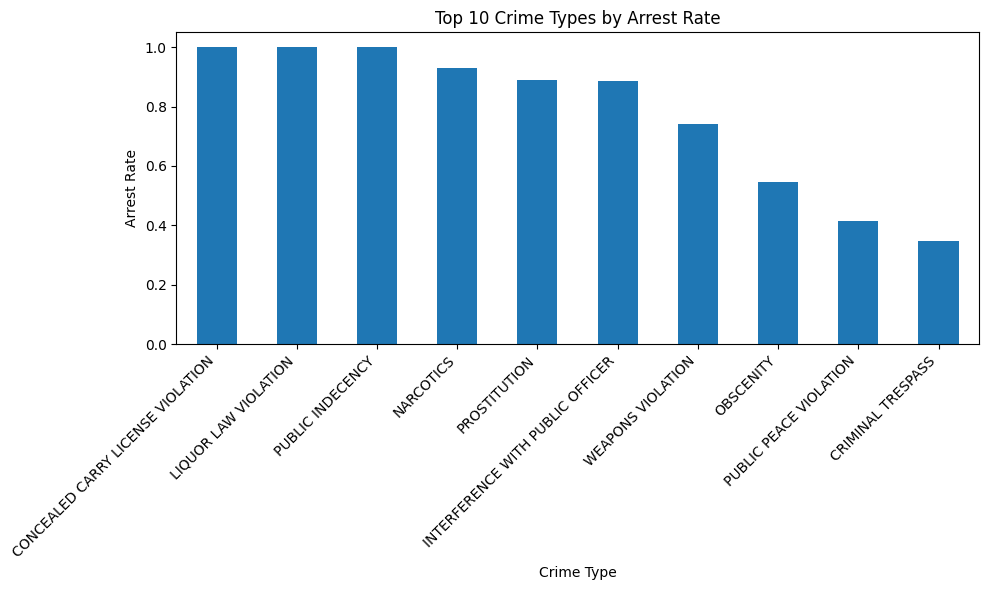

In [6]:
arrest_rates = df.groupby('primary_type')['arrest'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
arrest_rates.head(10).plot(kind='bar')
plt.title("Top 10 Crime Types by Arrest Rate")
plt.ylabel("Arrest Rate")
plt.xlabel("Crime Type")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretation Question
**Which crime types seem most likely to lead to arrest? Does this surprise you?**

The three crimes with the highest arrest rate seem to be concealed carry violations, liquor law violations and public indecency. These do not particularly surprise me as these types of crime are quite cut-and-dry, meaning there would be little defense if there was a witness to the crime.

## Step 6: Feature Engineering

Machine learning models need numeric input. Since `primary_type` and `district` are categorical, we will convert them into dummy variables.


In [7]:
df = pd.get_dummies(df, columns=['primary_type', 'district'], drop_first=True)
df.head()

,arrest,domestic,latitude,longitude,primary_type_ASSAULT,primary_type_BATTERY,primary_type_BURGLARY,primary_type_CONCEALED CARRY LICENSE VIOLATION,primary_type_CRIMINAL DAMAGE,primary_type_CRIMINAL SEXUAL ASSAULT,...,district_14,district_15,district_16,district_17,district_18,district_19,district_20,district_22,district_24,district_25
0,False,True,41.930870,-87.640820,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,False,False,41.770622,-87.733525,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,41.908928,-87.802695,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,41.903891,-87.632046,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,True,False,41.812611,-87.723765,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Step 7: Define Features and Target

Here is the key setup:

- `X` = the input features used to make predictions
- `y` = the target variable we want to predict

In this assignment:

> `y = arrest`

So the model predicts whether an arrest was made.


In [8]:
X = df.drop('arrest', axis=1)
y = df['arrest']

## Step 8: Train/Test Split

We split the data so the model trains on one portion and is evaluated on unseen data.


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 9: Train the Random Forest Model


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Step 10: Evaluate the Model

We will use:
- **Accuracy**
- **Confusion Matrix**
- **Classification Report**


In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8695608682604782

Confusion Matrix:
[[7953  445]
 [ 859  740]]

Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.95      0.92      8398
        True       0.62      0.46      0.53      1599

    accuracy                           0.87      9997
   macro avg       0.76      0.70      0.73      9997
weighted avg       0.86      0.87      0.86      9997



## Step 11: Feature Importance

Feature importance tells us which variables had the biggest influence on the model’s predictions.

A larger value means the model used that variable more heavily when making decisions.


In [12]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)
top_features

,0
latitude,0.328041
longitude,0.322087
primary_type_NARCOTICS,0.141180
primary_type_WEAPONS VIOLATION,0.059588
primary_type_INTERFERENCE WITH PUBLIC OFFICER,0.019531
domestic,0.010894
primary_type_CRIMINAL DAMAGE,0.010143
primary_type_CRIMINAL TRESPASS,0.009576
primary_type_BATTERY,0.008127
primary_type_MOTOR VEHICLE THEFT,0.008032


## Step 12: Visualize Feature Importance

This plot gives a clearer picture of what the model relied on most.


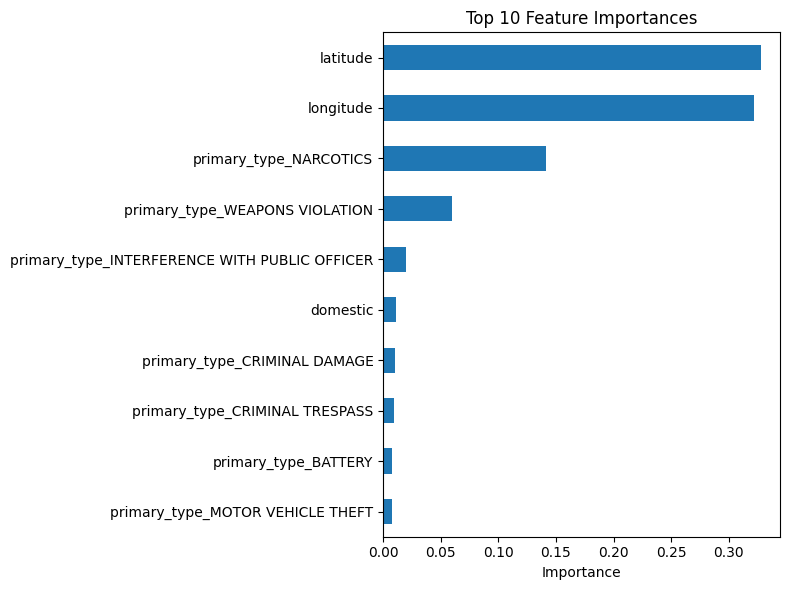

In [13]:
plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Interpretation Questions
1. Which features matter the most?

The 2 glaringly obvious features are latitude and longitude, obviously describing the location of the crime.

2. Does the model seem to rely more on **location** or **crime type**?

It seemeed to rely more on location as opposed to crime type.

3. What does that suggest about arrest outcomes in the dataset?

The dataset suggests that location is a dominant driver of arrest outcomes, meaning arrests are not just about the nature of the crime, but heavily influenced by where it happens.

## Step 13: Cross Validation

Cross validation helps us check whether the model performs consistently across different subsets of the data.


In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Average cross-validation score:", scores.mean())

Cross-validation scores: [0.86886066 0.8686606  0.87186156 0.87616285 0.86055817]
Average cross-validation score: 0.869220766229869


## Step 14: Reflection

Write a short reflection that answers the following:

1. What does the model do well?

The model does a good job in identifying patterns in the data and predicting arrest outcomes based on availible features.

2. What are its limitations?

The model is limited on the data that it is trained on. This could have negative implications of overreliance on features such as location, and could also lead to underrepresentation of contextual factors of the crime.

3. What does feature importance suggest about the strongest predictors of arrest?

Feature importance indicates that the location (lat. and long.) are the strongest predictor for arrest, more so than any of the crime types. This would suggest arrest outcomes are predicted more on the location of the crime compared to the crime itself.

4. Why is it important to remember that this model predicts **arrest outcomes** rather than crime itself?

This distinction is crucial because the model is learning patterns in police behavior, not patterns in criminal activity. Arrests are influenced by policing strategies, resource allocation, and potential biases, so the model reflects those systems rather than the true distribution of crime.


5. Should a model like this be used in real-world policing decisions? Why or why not?


A model like this should be used with extreme caution, if at all, because it may reinforce existing biases and disproportionately target certain areas. Relying on it for policing decisions could lead to unfair or discriminatory outcomes. If used, it should only support—not replace—human judgment, and must be carefully audited for bias and ethical implications.
